# **Open Global Workforce & Tech Salaries 2026 Dataset**

## **Descrição**

O dataset analisado é o **Open Global Workforce & Tech Salaries 2026**, obtido da base de dados do kaggle. O conjunto de dados conta com 12003 registros e 10 colunas, e as variáveis **salary_min_usd** e **salary_max_usd** serão a base para obtenção da variável alvo.  
  
link: **https://www.kaggle.com/datasets/saitejabandaruin/open-global-workforce-intelligence-2026**  
  
### **Features:**  
  
* job_id: Código de identificação único no formato alfanumérico, destinado a identificação da vaga.  
* job_title: Título do cargo ofertado.   
* company_name: Nome da empresa responsável pela oferta da vaga.  
* location: Local de atuação da vaga.  
* tech_stack: Tecnologias associadas aos requisitos da vaga.  
* source: Plataforma onde a vaga foi divulgada.  
* description: Descrição da vaga.  
* date_posted: Data de publicação da vaga.  

### **Variáveis utilizadas para criação do Target:**  
   
* salary_min_usd: Menor valor da faixa salarial anunciada para a vaga, em USD.  
* salary_max_usd: Maior valor da faixa salarial anunciada para a vaga, em USD.  
  
### **Target:**  
  
* salary_mean_usd: Valor médio da faixa salarial anunciada para a vaga, em USD.  

## **Objetivo**

O projeto tem por objetivo, treinar um modelo de rede neural de regressão, que estime o valor médio salarial ofertado à profissionais da área de tecnologia a partir de características presentes na base de dados.

## **Importação de Dados**

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

In [2]:
def div(mod=1):
    if mod == 0:
        print(50 * "-")
    elif mod == 1:
        print(130 * "-")
    elif mod == 2:
        print(130 * "=")
    else:
        print(50 * "-")

In [3]:
def save_df(file_path):
  PATH = "../datas/"
  DATA_PATH = f"{PATH}{file_path}"
  os.makedirs(PATH, exist_ok=True)
  if os.path.exists(DATA_PATH):
    return pd.read_csv(f"{PATH}{file_path}")
  df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "saitejabandaruin/open-global-workforce-intelligence-2026",
    file_path,
  )
  df.to_csv(f"{PATH}{file_path}", index=False)
  return df
df = save_df("global_tech_market_2026.csv")

## **Análise Exploratória**

In [4]:
df.head()

,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted
0,OGWIP_100001,Product Manager,European Space Agency,"Austin, TX, USA",81405,113143,"Python, SQL, TensorFlow, PyTorch",HackerNews,"We are European Space Agency, looking for a Pr...",2026-08-04 05:00:00
1,OGWIP_100003,NLP Engineer,Federal Bureau of Investigation,Remote - US Only,74906,118550,"Java, Spring Boot, Kafka, PostgreSQL",LinkedIn_Proxy,"We are Federal Bureau of Investigation, lookin...",2026-08-01 13:00:00
2,OGWIP_100004,Lead Data Scientist,AI Solutions LLC,Remote - Global,144270,215864,"Go, Kubernetes, Docker, GCP",LinkedIn_Proxy,"We are AI Solutions LLC, looking for a Lead Da...",2026-08-04 21:00:00
3,OGWIP_100005,Full Stack Developer,NASA,"Seattle, WA, USA",109716,165103,"Python, Airflow, Snowflake, dbt",HackerNews,"We are NASA, looking for a Full Stack Develope...",2026-08-02 22:00:00
4,OGWIP_100006,Technical Program Manager,Quantum Data,"Amsterdam, Netherlands",73276,111586,"JavaScript, React, Node.js, MongoDB",HackerNews,"We are Quantum Data, looking for a Technical P...",2026-08-02 05:00:00


In [5]:
df.shape

(12003, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12003 entries, 0 to 12002
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   job_id          12003 non-null  str  
 1   job_title       12003 non-null  str  
 2   company_name    12003 non-null  str  
 3   location        12003 non-null  str  
 4   salary_min_usd  12003 non-null  int64
 5   salary_max_usd  12003 non-null  int64
 6   tech_stack      12003 non-null  str  
 7   source          12003 non-null  str  
 8   description     12003 non-null  str  
 9   date_posted     12003 non-null  str  
dtypes: int64(2), str(8)
memory usage: 4.8 MB


In [7]:
df.nunique()

job_id            12003
job_title            20
company_name         17
location             16
salary_min_usd    11244
salary_max_usd    11503
tech_stack           10
source                4
description       12003
date_posted         101
dtype: int64

In [8]:
df.describe()

,salary_min_usd,salary_max_usd
count,12003.000000,12003.000000
mean,100923.489794,141565.404316
std,34277.942625,49137.782038
min,32013.000000,42002.000000
25%,79094.000000,108922.500000
50%,92003.000000,131587.000000
75%,120280.500000,170455.500000
max,221927.000000,326671.000000


## **Tratamento dos Dados**

In [9]:
print("Criação de variáveis dummy para tech_stack:")
dim_df = df.copy()
print(f"Total de features antes do tratamento: {df.shape[1]} features")
div()
if "job_title" in df.columns:
    df["job_title"] = df["job_title"].str.lower().str.strip()
    job_dummies = df["job_title"].str.get_dummies()
    df = pd.concat([df, job_dummies], axis=1)
    df.drop(columns=["job_title"], inplace=True)
    print(f"Criação de {job_dummies.shape[1]} variáveis dummy para 'job_title'!")
    print("Remoção da variável 'job_title'!")
if "location" in df.columns:
    df.loc[df["location"].str.lower().str.startswith("remote"), "location"] = "remote"
    df["location"] = df["location"].str.lower().str.split(",").str[-1].str.strip()
    location_dummies = df["location"].str.get_dummies()
    df = pd.concat([df, location_dummies], axis=1)
    df.drop(columns=["location"], inplace=True)
    print(f"Criação de {location_dummies.shape[1]} variáveis dummy para 'location'!")
    print("Remoção da variável 'location'!")
if "tech_stack" in df.columns:
    tech_dummies = df["tech_stack"].str.lower().str.get_dummies(sep=",")
    tech_dummies.columns = tech_dummies.columns.str.strip()
    df = pd.concat([df, tech_dummies], axis=1)
    df.drop(columns=["tech_stack"], inplace=True)
    print(f"Criação de {tech_dummies.shape[1]} variáveis dummy para 'tech_stack'!")
    print("Remoção da variável 'tech_stack'!")
div()
print(f"Total de features após do tratamento: {df.shape[1]} features")

Criação de variáveis dummy para tech_stack:
Total de features antes do tratamento: 10 features
----------------------------------------------------------------------------------------------------------------------------------
Criação de 20 variáveis dummy para 'job_title'!
Remoção da variável 'job_title'!
Criação de 10 variáveis dummy para 'location'!
Remoção da variável 'location'!
Criação de 34 variáveis dummy para 'tech_stack'!
Remoção da variável 'tech_stack'!
----------------------------------------------------------------------------------------------------------------------------------
Total de features após do tratamento: 71 features


In [10]:
print("Padronização de nomes de variáveis:")
div(0)
print("Nomes das colunas antes do tratamento:")
print(df.columns)
df.columns = df.columns.str.lower().str.replace(" ", "_")
div()
print("Nomes das colunas após o tratamento:")
print(df.columns)

Padronização de nomes de variáveis:
--------------------------------------------------
Nomes das colunas antes do tratamento:
Index(['job_id', 'company_name', 'salary_min_usd', 'salary_max_usd', 'source',
       'description', 'date_posted', 'ai researcher', 'analytics engineer',
       'backend developer', 'cloud architect', 'cybersecurity analyst',
       'data engineer', 'data scientist', 'devops engineer',
       'frontend developer', 'full stack developer', 'lead data scientist',
       'machine learning engineer', 'nlp engineer', 'product manager',
       'senior data scientist', 'senior software engineer',
       'site reliability engineer', 'software engineer', 'staff engineer',
       'technical program manager', 'australia', 'canada', 'france', 'germany',
       'india', 'netherlands', 'remote', 'singapore', 'uk', 'usa', 'airflow',
       'angular', 'aws', 'computer vision', 'cuda', 'dbt', 'docker',
       'firebase', 'gcp', 'heroku', 'kafka', 'kubernetes', 'mongodb',
       

In [11]:
print("Remoção das variáveis 'description' e 'date_posted':")
print(f"Total de features antes da limpeza: {df.shape[1]} features")
div()
if "job_id" in df.columns:
    df.drop(columns=["job_id"], inplace=True)
    print("Remoção da variável 'job_id'!")
if "company_name" in df.columns:
    df.drop(columns=["company_name"], inplace=True)
    print("Remoção da variável 'company_name'!")
if "source" in df.columns:
    df.drop(columns=["source"], inplace=True)
    print("Remoção da variável 'source'!")
if "description" in df.columns:
    df.drop(columns=["description"], inplace=True)
    print("Remoção da variável 'description'!")
if "date_posted" in df.columns:
    df.drop(columns=["date_posted"], inplace=True)
    print("Remoção da variável 'date_posted'!")
div()
print(f"Total de features após a limpeza: {df.shape[1]} features")

Remoção das variáveis 'description' e 'date_posted':
Total de features antes da limpeza: 71 features
----------------------------------------------------------------------------------------------------------------------------------
Remoção da variável 'job_id'!
Remoção da variável 'company_name'!
Remoção da variável 'source'!
Remoção da variável 'description'!
Remoção da variável 'date_posted'!
----------------------------------------------------------------------------------------------------------------------------------
Total de features após a limpeza: 66 features


In [12]:
print("Criação da variável 'salary_mean_usd' e remoção das variáveis 'salary_min_usd' e salary_max_usd':")
print(f"Total de features antes do tratamento: {df.shape[1]} features")
div()
if "salary_mean_usd" not in df.columns:
    df["salary_mean_usd"] = df.loc[:, ["salary_min_usd", "salary_max_usd"]].mean(axis=1)
    cols = df.columns.to_list()
    cols.remove("salary_mean_usd")
    pos = cols.index("salary_max_usd") + 1
    cols.insert(pos, "salary_mean_usd")
    df = df[cols]
    print(f"Criação da variável 'salary_mean_usd'!")
if "salary_min_usd" in df.columns:
    df.drop(columns=["salary_min_usd"], inplace=True)
    print("Remoção da variável 'salary_min_usd'!")
if "salary_max_usd" in df.columns:
    df.drop(columns=["salary_max_usd"], inplace=True)
    print("Remoção da variável 'salary_max_usd'!")
div()
print(f"Total de features após do tratamento: {df.shape[1]} features")


Criação da variável 'salary_mean_usd' e remoção das variáveis 'salary_min_usd' e salary_max_usd':
Total de features antes do tratamento: 66 features
----------------------------------------------------------------------------------------------------------------------------------
Criação da variável 'salary_mean_usd'!
Remoção da variável 'salary_min_usd'!
Remoção da variável 'salary_max_usd'!
----------------------------------------------------------------------------------------------------------------------------------
Total de features após do tratamento: 65 features


In [13]:
def save_treated_df(df, filepath):
    PATH = "../datas/"
    DATA_PATH = f"{PATH}{filepath}"

    os.makedirs(PATH, exist_ok=True)
    if not os.path.exists(DATA_PATH):
        df.to_csv("../datas/global_tech_market_2026_treated.csv", index=False)
        df = pd.read_csv(DATA_PATH)
    return df
df = save_treated_df(df, "global_tech_market_2026_treated.csv")

## **Preparação dos Dados**

In [14]:
X = df.loc[:, df.columns != "salary_mean_usd"]
y = df["salary_mean_usd"]
features = X.columns.tolist()
X_np = X.to_numpy(dtype=np.float32)
y_np = y.to_numpy(dtype=np.float32).reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=.2, random_state=123)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=.2, random_state=123)
print(f"X_train: {X_train.shape}\nX_test: {X_test.shape}\nX_val: {X_val.shape}\ny_train: {y_train.shape}\ny_test: {y_test.shape}\ny_val: {y_val.shape}")

X_train: (7681, 64)
X_test: (2401, 64)
X_val: (1921, 64)
y_train: (7681, 1)
y_test: (2401, 1)
y_val: (1921, 1)


In [15]:
y_scaler = StandardScaler()
y_train_scaler = y_scaler.fit_transform(y_train)
y_test_scaler = y_scaler.transform(y_test)
y_val_scaler = y_scaler.transform(y_val)

In [16]:
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
X_val = torch.from_numpy(X_val)
y_train = torch.from_numpy(y_train_scaler)
y_test = torch.from_numpy(y_test_scaler)
y_val = torch.from_numpy(y_val_scaler)
print(f"X_train: {X_train.shape}\nX_test: {X_test.shape}\nX_val: {X_val.shape}\ny_train: {y_train.shape}\ny_test: {y_test.shape}\ny_val: {y_val.shape}")

X_train: torch.Size([7681, 64])
X_test: torch.Size([2401, 64])
X_val: torch.Size([1921, 64])
y_train: torch.Size([7681, 1])
y_test: torch.Size([2401, 1])
y_val: torch.Size([1921, 1])


## **Configuração do Modelo**

In [17]:
class OpenGlobalWorkforceData(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [18]:
class OpenGlobalWorkforceModel(nn.Module):
    def __init__(self, input_size, output_size, architecture):
        super(OpenGlobalWorkforceModel, self).__init__()
        layers = []
        previous_size = input_size
        for neurons in architecture:
            layers.append(nn.Linear(previous_size, neurons))
            layers.append(nn.ReLU())
            previous_size = neurons
        layers.append(nn.Linear(previous_size, output_size))
        self.model = nn.Sequential(*layers)
    def forward(self, X):
        return self.model(X)

## **Treinamento**

In [19]:
def arc_save():
    PATH = f"../models/"
    ARCPATH = f"{PATH}architectures.pkl"

    architectures = {
        "32": [32],
        "64": [64],
        "128": [128],
        "64-32": [64, 32],
        "128-64": [128, 64],
    }

    os.makedirs(PATH, exist_ok=True)
    if not os.path.exists(ARCPATH):
        joblib.dump(architectures, ARCPATH)
    architectures = joblib.load(ARCPATH)
    return architectures
architectures = arc_save()


In [20]:
def model_train(X_train, y_train, X_val, y_val):
    train_loader = DataLoader(OpenGlobalWorkforceData(X_train, y_train), batch_size=32, shuffle=True)

    #Parametros
    input_dim = X_train.shape[1]
    output_dim = 1
    LR = .0001
    NUM_EPOCHS = 1000
    
    results = {}
    for name, architecture in architectures.items():
        losses, val_losses, weights, bias = [], [], [], []
        model = OpenGlobalWorkforceModel(input_size=input_dim, output_size=output_dim, architecture=architecture)
        loss_fn = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=LR)

        for epoch in range(NUM_EPOCHS):
            model.train()
            epoch_loss = 0
            for data in train_loader:
                optimizer.zero_grad()
                y_pred = model(data[0])
                loss = loss_fn(y_pred, data[1])
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            losses.append(epoch_loss / len(train_loader))
            weights.append(model.model[-1].weight.detach().cpu().numpy()[0].copy())
            bias.append(model.model[-1].bias.detach().cpu().numpy()[0].copy())
            if epoch % 100 == 0:
                print(f"Arquitetura: {name} | Epoch: {epoch} | Loss: {losses[-1]:.4f}")
            model.eval()
            with torch.no_grad():
                y_val_pred = model(X_val)
                val_loss = loss_fn(y_val_pred, y_val)
            val_losses.append(val_loss.item())
        results[name] = {
            "model": model,
            "losses": losses,
            "val_losses": val_losses,
            "weights": weights,
            "bias": bias,
            "features": features,
            "y_scaler": y_scaler,
        }
    return results

In [21]:
def save_model(model, input_size, output_size, losses, val_losses, weights, bias, features, y_scaler):
    PATH = f"../models/{architecture}/"
    MODELPATH = f"{PATH}model.pth"

    os.makedirs(PATH, exist_ok=True)
    torch.save({
        "model_state_dict": model.state_dict(),
        "input_size": input_size,
        "output_size": output_size,
        "losses": losses,
        "val_losses": val_losses,
        "weights": weights,
        "bias": bias,
        "features": features,
        "y_scaler": y_scaler,
    }, MODELPATH)

def load_model(architecture):
    PATH = f"../models/{architecture}/"
    MODELPATH = f"{PATH}model.pth"
    checkpoint = torch.load(MODELPATH, weights_only=False)
    model = OpenGlobalWorkforceModel(
        input_size=checkpoint["input_size"],
        output_size=checkpoint["output_size"],
        architecture=architectures[architecture]
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    return {
        "model": model,
        "losses": checkpoint["losses"],
        "val_losses": checkpoint["val_losses"],
        "weights": checkpoint["weights"],
        "bias": checkpoint["bias"],
        "features": checkpoint["features"],
        "y_scaler": checkpoint["y_scaler"],
    }

def models_exist(architectures):
    for architecture in architectures:
        PATH = f"../models/{architecture}/"
        MODELPATH = f"{PATH}model.pth"
        if not os.path.exists(MODELPATH):
            return False
    return True

In [22]:
if models_exist(architectures=architectures):
    print("Modelos já salvos.")
    result_train = {}
    for architecture in architectures:
        result_train[architecture] = load_model(architecture)
else:
    print("Treinando modelos...")
    result_train = model_train(X_train, y_train, X_val, y_val)
    for architecture in architectures:
        save_model(
            model=result_train[architecture]["model"],
            input_size=X_train.shape[1],
            output_size=1,
            losses=result_train[architecture]["losses"],
            val_losses=result_train[architecture]["val_losses"],
            weights=result_train[architecture]["weights"],
            bias=result_train[architecture]["bias"],
            features=result_train[architecture]["features"],
            y_scaler=result_train[architecture]["y_scaler"],
            )

Modelos já salvos.


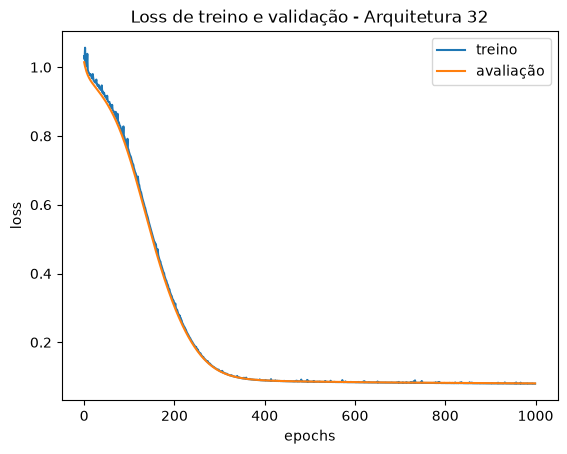

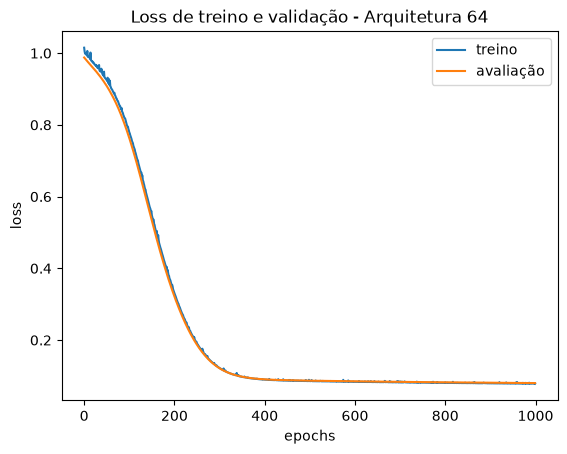

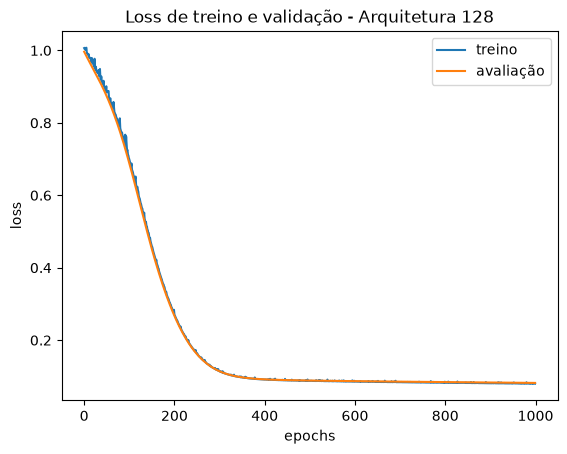

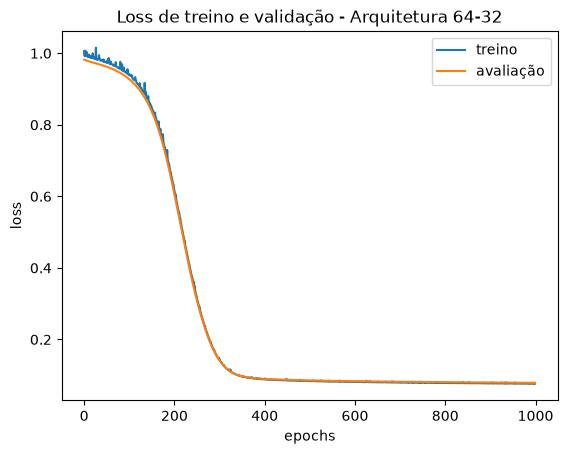

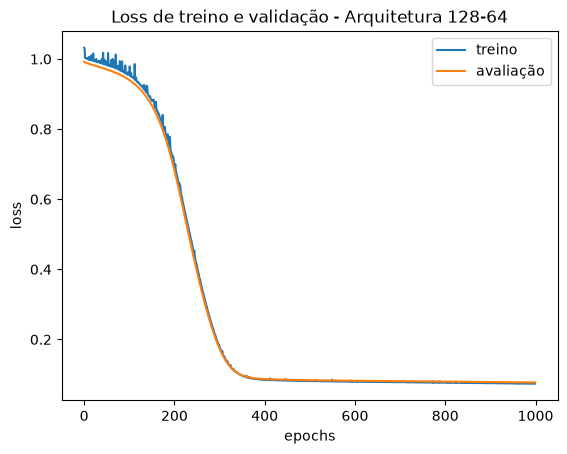

In [23]:
for architecture in architectures.keys():
    sns.lineplot(result_train[architecture]["losses"], label="treino")
    sns.lineplot(result_train[architecture]["val_losses"], label="avaliação")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.title(f"Loss de treino e validação - Arquitetura {architecture}")
    plt.legend()
    plt.show()

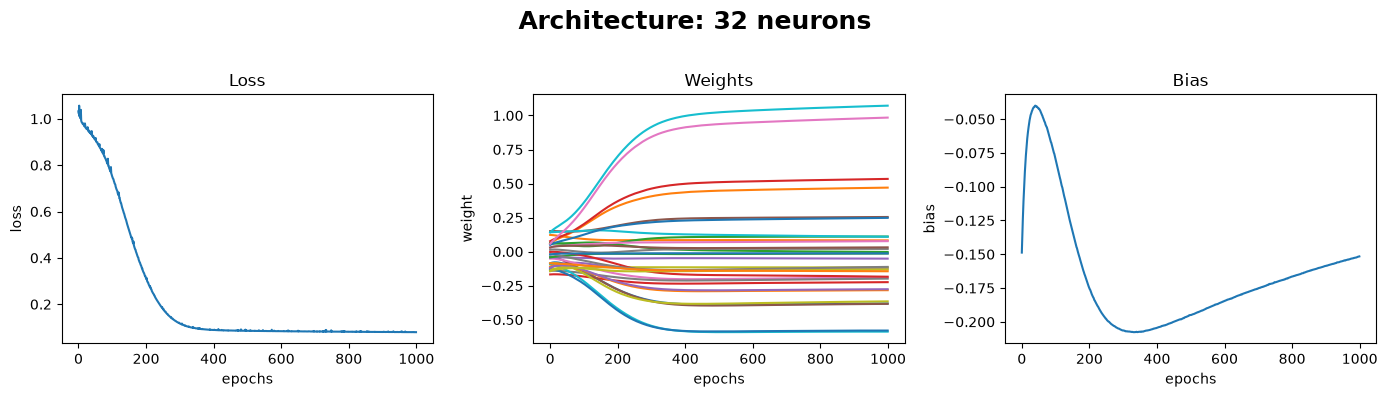

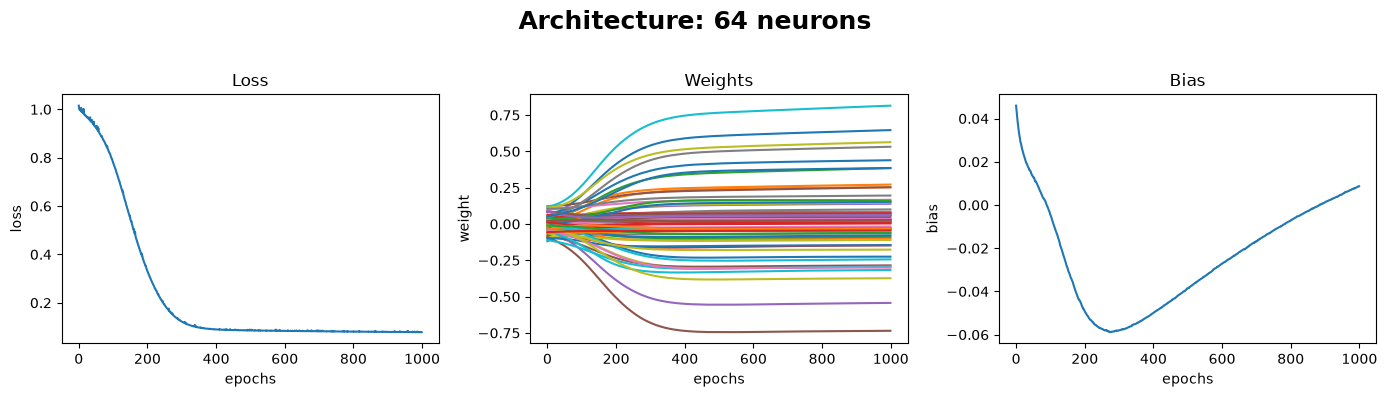

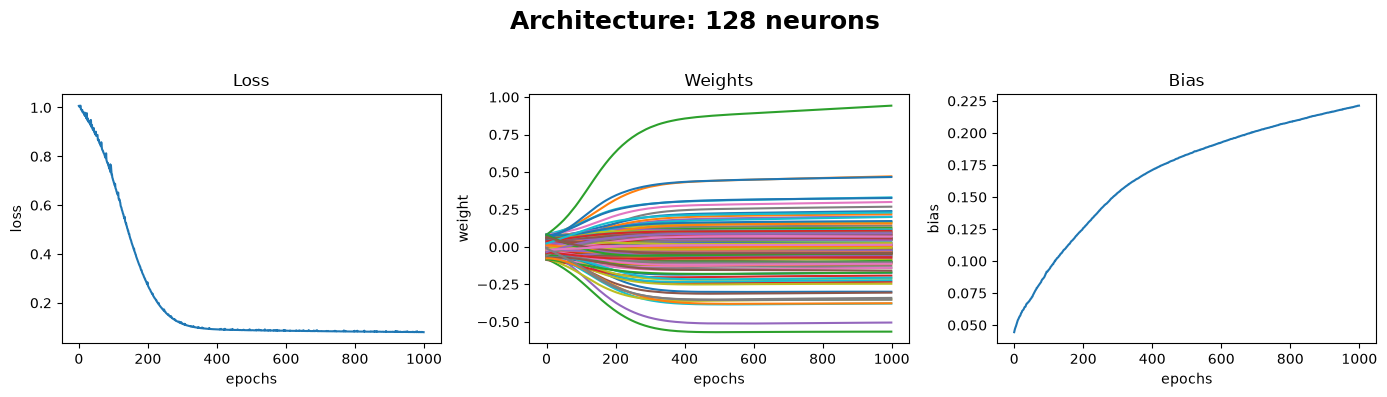

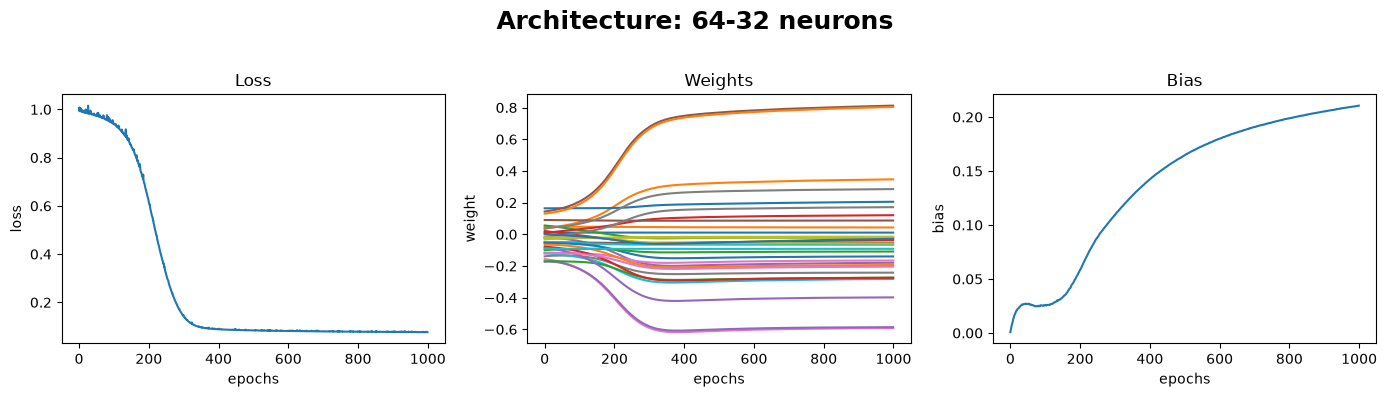

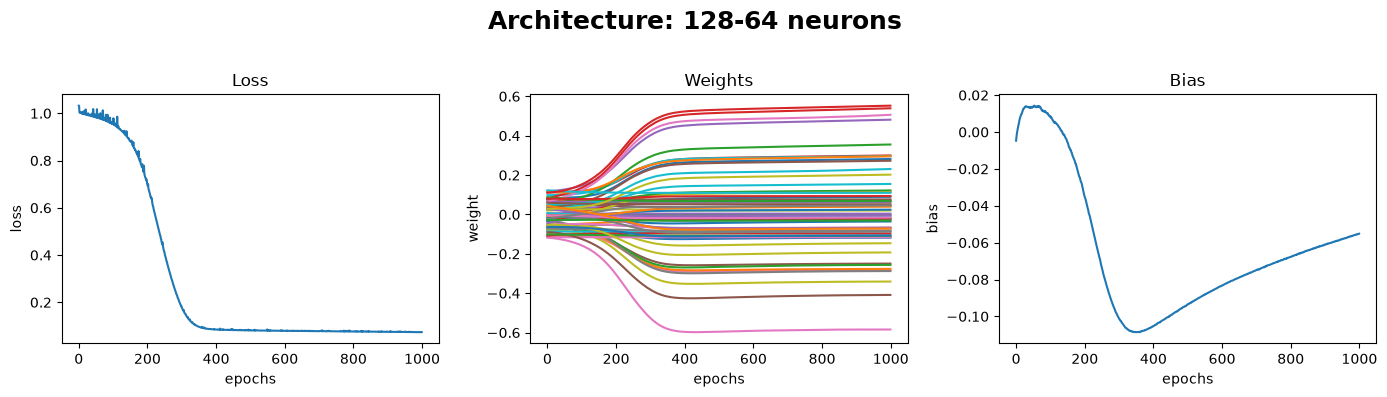

In [24]:
for architecture in list(architectures.keys()):
    fig, axs = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"Architecture: {architecture} neurons", fontsize=18, fontweight="bold")
    sns.lineplot(result_train[architecture]["losses"], ax=axs[0])
    axs[0].set_title("Loss")
    axs[0].set(xlabel="epochs", ylabel="loss")
    weights = np.array(result_train[architecture]["weights"])
    [sns.lineplot(weights[:, i], ax=axs[1]) for i in range(weights.shape[1])]
    axs[1].set_title("Weights")
    axs[1].set(xlabel="epochs", ylabel="weight")
    sns.lineplot(result_train[architecture]["bias"], ax=axs[2])
    axs[2].set_title("Bias")
    axs[2].set(xlabel="epochs", ylabel="bias")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## **Avaliação**

In [ ]:
def model_eval(model, X_test, y_test_scaled, y_scaler):
    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(X_test)
    y_pred_scaled = y_pred_scaled.cpu().numpy()
    if torch.is_tensor(y_test_scaled):
        y_test_scaled = y_test_scaled.cpu().numpy()
    else:
        y_test_scaled = y_test_scaled
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    y_test_original = y_scaler.inverse_transform(y_test_scaled)
    mae = mean_absolute_error(y_test_original, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
    r2 = r2_score(y_test_original, y_pred)
    return {
        "y_pred": y_pred,
        "y_test": y_test_original,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }

def evaluate_models(result_train, X_test, y_test):
    results = []
    for architecture in result_train:
        model = result_train[architecture]["model"]
        y_scaler = result_train[architecture]["y_scaler"]
        result_eval = model_eval(model, X_test, y_test, y_scaler)
        results.append({
            "architecture": architecture,
            "mae": result_eval["mae"],
            "rmse": result_eval["rmse"],
            "r2": result_eval["r2"]
        })
    return pd.DataFrame(results)

In [26]:
results_eval = evaluate_models(result_train=result_train, X_test=X_test, y_test=y_test)
results_eval.sort_values("r2", ascending=False)

,architecture,mae,rmse,r2
4,128-64,7922.839844,11455.214708,0.924426
3,64-32,8079.919434,11651.838653,0.921809
1,64,8229.492188,11856.031714,0.919044
0,32,8239.486328,11937.329014,0.917930
2,128,8347.980469,11951.527434,0.917735


In [27]:
def y_metrics(result_train, X_test, y_test_scaled, architecture):
    model = result_train[architecture]["model"]
    y_scaler = result_train[architecture]["y_scaler"]
    result_eval = model_eval(model=model, X_test=X_test, y_test_scaled=y_test_scaled, y_scaler=y_scaler)
    return result_eval["y_pred"], result_eval["y_test"]

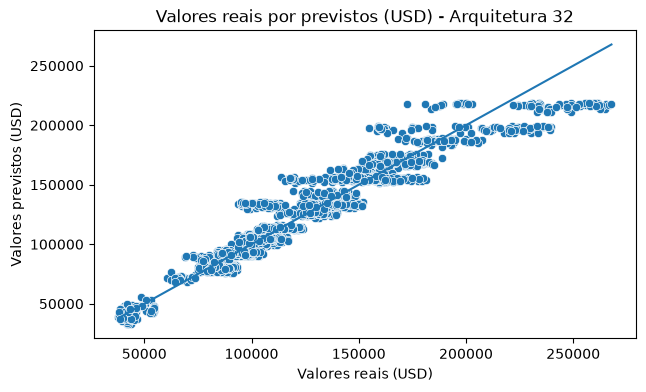

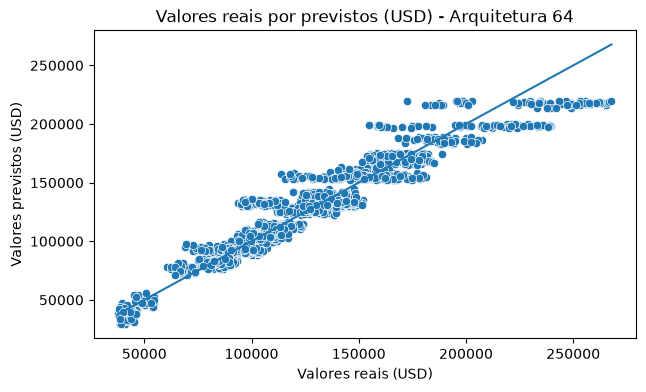

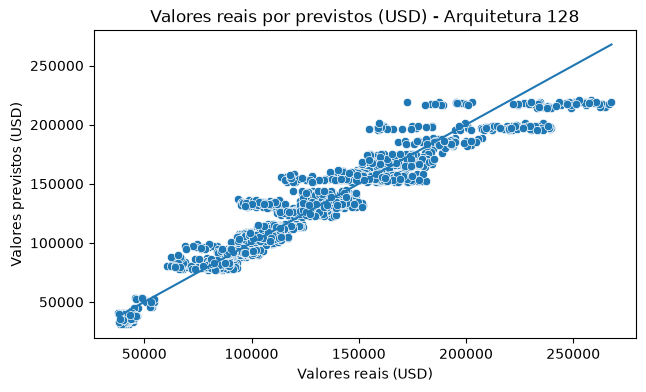

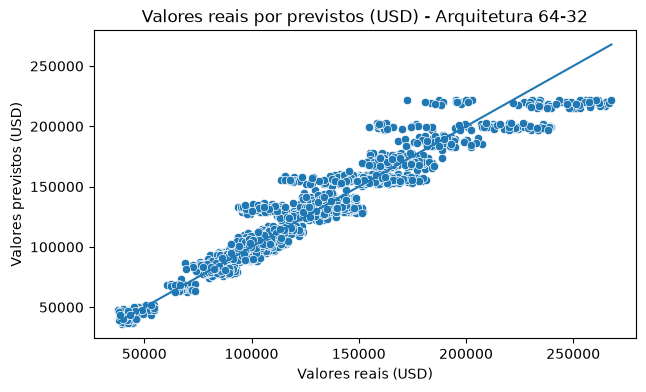

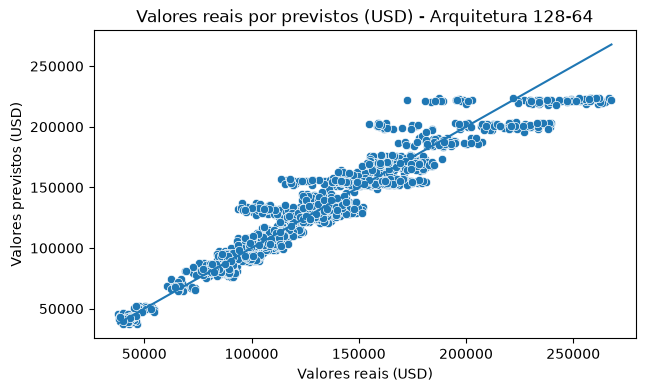

In [28]:
for architecture in architectures.keys():
    y_pred_original, y_test_original = y_metrics(result_train=result_train, X_test=X_test, y_test_scaled=y_test, architecture=architecture)
    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=y_test_original.flatten(), y=y_pred_original.flatten())
    plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()])
    plt.title(f"Valores reais por previstos (USD) - Arquitetura {architecture}")
    plt.xlabel("Valores reais (USD)")
    plt.ylabel("Valores previstos (USD)")
    plt.show()

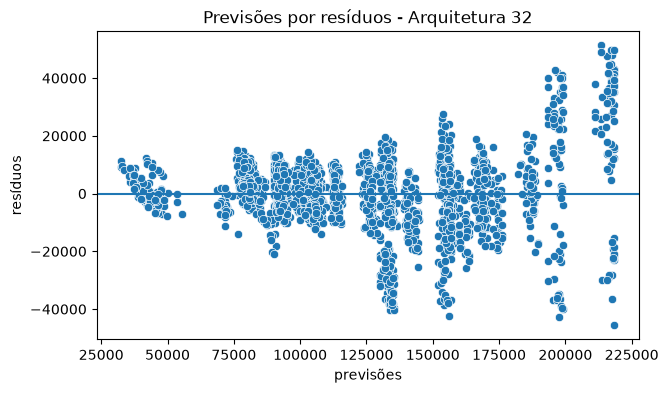

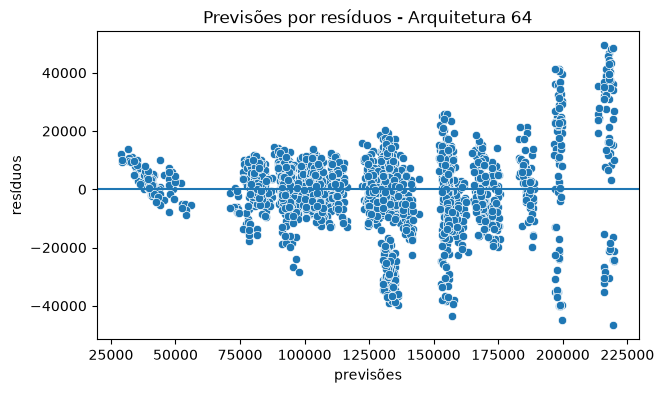

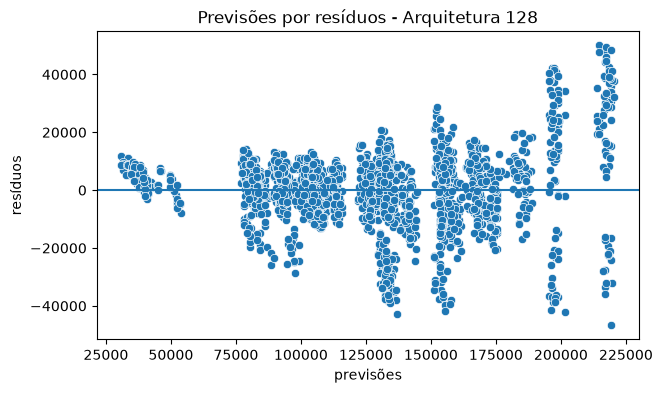

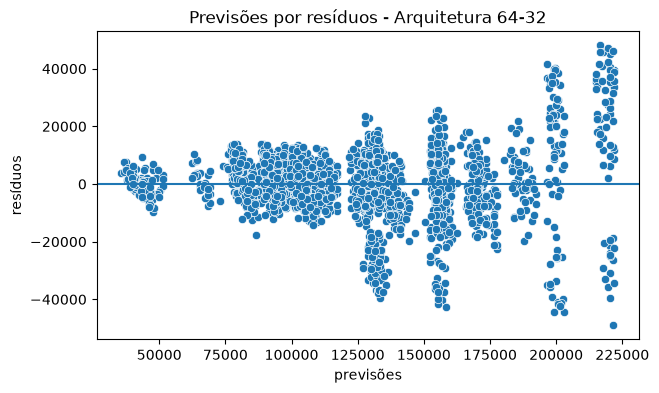

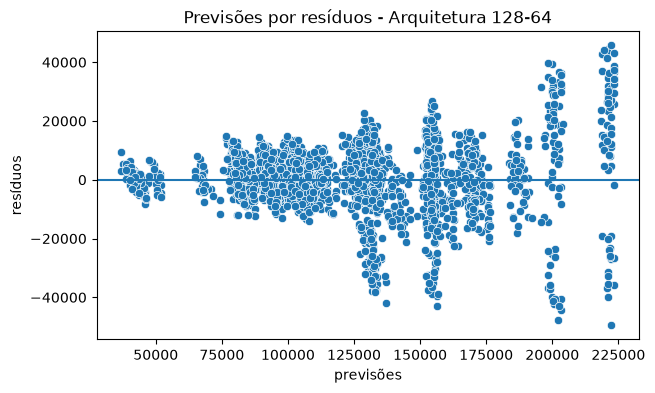

In [29]:
for architecture in architectures.keys():
    plt.figure(figsize=(7, 4))
    y_pred_original, y_test_original = y_metrics(result_train=result_train, X_test=X_test, y_test_scaled=y_test, architecture=architecture)
    residuos = y_test_original - y_pred_original
    sns.scatterplot(x=y_pred_original.flatten(), y=residuos.flatten())
    plt.axhline(0)
    plt.title(f"Previsões por resíduos - Arquitetura {architecture}")
    plt.xlabel("previsões")
    plt.ylabel("resíduos")
    plt.show()

## **Conclusão**

Este projeto teve como objetivo inicial, a criação de um modelo de regressão linear que pudesse identificar a média salarial de profissionais da tecnologia, a partir de dados característicos da sua profissão. O modelo inicialmente possuía 10 variáveis advindas diretamente da base de dados obtida na plataforma do Kaggle, onde 2 dessas variáveis **salary_min_usd** e **salary_max_usd**, servem de base para obtenção da variável resposta **salary_mean_usd**, em contrapartida, as 8 variáveis restantes fornecem as 64 novas variáveis de entrada do modelo. 

Com uma análise aprofundada nos dados, identificou-se entre os registros da variável **company_name**, nomes de empresas conhecidos dentro da cultura pop, indicando que possivelmente foram retirados de uma obra de ficção, como **Umbrella Corp**, **Stark Industries**, **Wayne Enterprises** e **CyberDyne**, o que sugere que a base passou por um processo de aumento artificial de dados, ou que toda ela tenha sido criada artificialmente. Por fim, para melhorar a otimização dos dados, bem como facilitar a obtenção dos pesos, e ao mesmo tempo obter resultados em uma escala mais agradável para visualização, os dados da variável de saída foram normalizados com o uso do **StandardScaler**.

Com o treino e avaliação do modelo, e com as análises realizadas ao longo do projeto identificou-se que um modelo simples de regressão, não se ajustaria bem as complexidades nas relações entre as features e a label do modelo, sinalizando uma provável relação não linear entre elas. Na tentativa de obter melhores resultados, optou-se pela adição de camadas ocultas, buscando aumentar a capacidade do modelo de encontrar padrões não lineares presentes nos dados, transformando-o de uma regressão linear simples para uma rede neural de regressão.  

Após a mudança, foram adicionados 5 modelos de arquiteturas de redes neurais a serem treinados, e comparando os resultados de cada uma delas, pôde-se identificar quais melhor respondiam às features de entrada. Dentre as arquiteturas treinadas, a que melhor respondeu a base de dados e retornou métricas mais favoráveis, foi a de **128-64** que dispunha de 2 camadas ocultas estimuladas por uma função de ativação ReLU. como resultado obteve-se um R² de 0.9244, um erro MAE de US$7922.84 e um erro RMSE de US$11455.21.